# Modélisation — BRFSS Heart Disease (modèle lifestyle)

Objectif : entraîner et comparer plusieurs modèles de Machine Learning pour prédire une cardiopathie
(`HeartDiseaseorAttack`) à partir de données déclaratives (habitudes de vie, indicateurs de santé
perçue, contexte socio-économique) — sans mesures cliniques précises.

Particularité de ce dataset : il est **fortement déséquilibré** (~10% de cas positifs), ce qui
conditionne à la fois l'entraînement (pondération des classes) et l'évaluation (le ROC-AUC est
préféré à l'accuracy).

La logique d'entraînement est centralisée dans `src/train_model.py` — ce notebook l'exécute pas à
pas pour documenter et visualiser la démarche.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.feature_engineering import add_bmi_category, add_unhealthy_days
from src.evaluate_model import compute_metrics, compute_confusion_matrix, compute_roc_curve
from src.train_model import build_models

sns.set_style("whitegrid")

## 1. Chargement et feature engineering

Le dataset `processed/heart_disease.csv` est déjà nettoyé (voir `01_data_cleaning.ipynb`). On y
ajoute deux variables dérivées :
- `bmi_category` : catégorie d'IMC (seuils OMS)
- `unhealthy_days` : cumul des jours de santé mentale + physique difficile sur 30 jours (0–60),
  un indicateur global de fragilité qui combine deux variables corrélées

In [2]:
df = pd.read_csv("../../data/processed/heart_disease.csv")
df = add_bmi_category(df)
df = add_unhealthy_days(df)

print(df.shape)
print(f"Prévalence de la cible : {df['HeartDiseaseorAttack'].mean():.1%}")
df.head()

(229781, 24)
Prévalence de la cible : 10.3%


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,bmi_category,unhealthy_days
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,3,33.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,2,0.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,2,60.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,2,0.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,1,3.0


## 2. Split train / test

Split stratifié 80/20 — la stratification est cruciale ici : avec seulement ~10% de cas positifs,
un split aléatoire non stratifié pourrait produire un échantillon de test non représentatif.

In [3]:
TARGET = "HeartDiseaseorAttack"
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} répondants | Test : {X_test.shape[0]:,} répondants")
print(f"Prévalence — train : {y_train.mean():.1%} | test : {y_test.mean():.1%}")

Train : 183,824 répondants | Test : 45,957 répondants
Prévalence — train : 10.3% | test : 10.3%


## 3. Gestion du déséquilibre et entraînement des 4 modèles

Avec 90% de "sains", un modèle naïf qui prédit toujours "sain" atteindrait 90% d'accuracy tout en
étant inutile. Deux parades sont utilisées :
- `class_weight="balanced"` (Logistic Regression, Random Forest, LightGBM) : les erreurs sur la
  classe minoritaire pèsent plus lourd dans la fonction de coût
- `scale_pos_weight` (XGBoost) : équivalent, ratio négatifs/positifs

Et surtout, l'évaluation repose sur le **ROC-AUC** plutôt que l'accuracy.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

results = {}
fitted_models = {}

for name, model in build_models(scale_pos_weight).items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    metrics = compute_metrics(y_test, y_pred, y_proba)
    metrics["confusion_matrix"] = compute_confusion_matrix(y_test, y_pred)
    metrics["roc_curve"] = compute_roc_curve(y_test, y_proba)

    results[name] = metrics
    fitted_models[name] = model

comparison = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "roc_auc"]].astype(float).round(3)
comparison

scale_pos_weight = 8.7


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.739,0.253,0.780,0.382,0.835
Random Forest,0.745,0.255,0.769,0.383,0.834
XGBoost,0.741,0.252,0.769,0.380,0.832
LightGBM,0.736,0.251,0.789,0.381,0.836


## 4. Lecture des résultats et sélection

On observe l'effet du déséquilibre : le **F1-score est bas (~0.38)** pour tous les modèles alors que
le ROC-AUC est bon (~0.83). C'est attendu — avec la pondération des classes, les modèles acceptent
beaucoup de faux positifs pour capter les vrais malades (recall élevé, précision basse). Dans un
contexte de dépistage, c'est le bon compromis : rater un malade coûte plus cher qu'une fausse alerte.

Sélection par **ROC-AUC**, indépendant du seuil de décision.

In [5]:
best_name = comparison["roc_auc"].idxmax()
best_model = fitted_models[best_name]

print(f"Meilleur modèle : {best_name}")
print(f"ROC-AUC = {comparison.loc[best_name, 'roc_auc']:.3f}")

Meilleur modèle : LightGBM
ROC-AUC = 0.836


## 5. Courbes ROC des 4 modèles

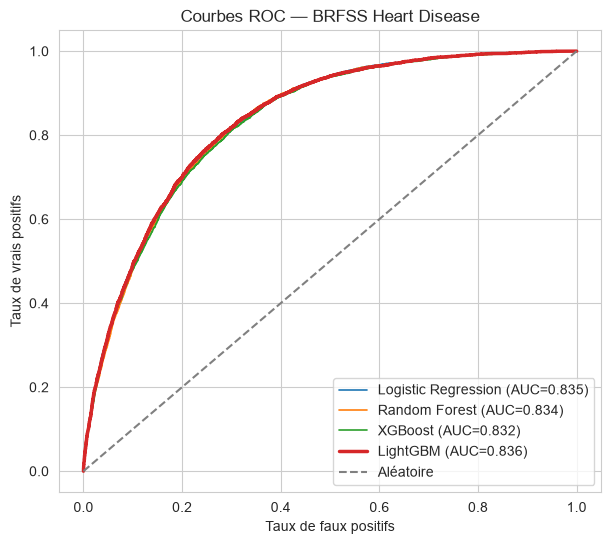

In [6]:
plt.figure(figsize=(7, 6))
for name, metrics in results.items():
    lw = 2.5 if name == best_name else 1.2
    plt.plot(
        metrics["roc_curve"]["fpr"], metrics["roc_curve"]["tpr"],
        label=f"{name} (AUC={metrics['roc_auc']:.3f})", linewidth=lw,
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — BRFSS Heart Disease")
plt.legend()
plt.show()

## 6. Matrice de confusion et feature importance du meilleur modèle

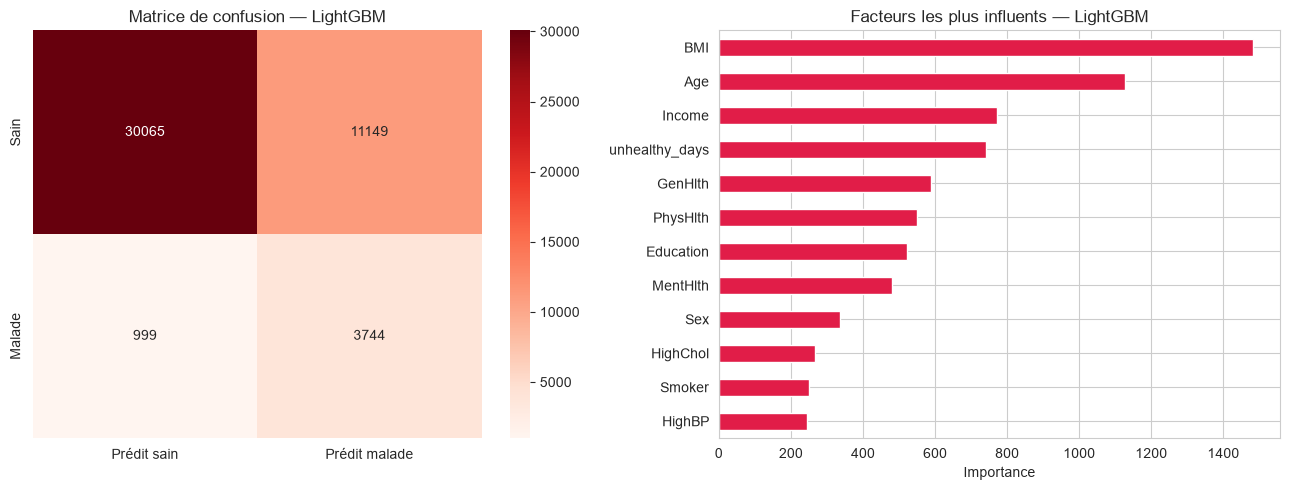

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = results[best_name]["confusion_matrix"]
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds", ax=axes[0],
    xticklabels=["Prédit sain", "Prédit malade"], yticklabels=["Sain", "Malade"],
)
axes[0].set_title(f"Matrice de confusion — {best_name}")

if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=feature_names)
elif hasattr(best_model, "coef_"):
    importance = pd.Series(best_model.coef_[0], index=feature_names)

importance = importance.abs().sort_values(ascending=False).head(12).sort_values()
importance.plot.barh(ax=axes[1], color="#e11d48")
axes[1].set_title(f"Facteurs les plus influents — {best_name}")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## Conclusion

Les 4 modèles sont très proches (ROC-AUC 0.83–0.84), **LightGBM** l'emporte de peu. La matrice de
confusion illustre le compromis assumé : beaucoup de faux positifs, mais un bon rappel des vrais
malades — cohérent avec un usage de dépistage grand public.

Fait notable : sans aucune mesure clinique précise, ce modèle "lifestyle" atteint un ROC-AUC
*supérieur* au modèle clinique (0.84 vs 0.81). L'interprétation détaillée est dans
`04_interpretation.ipynb`. Le pipeline persisté (`models/heart_disease/`) est régénéré par
`python -m src.train_model`.